**1. KÜTÜPHANELER ve VERİ YÜKLEME**

In [ ]:
# Kütüphanelerin içe aktarılması (import)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action="ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 500)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

df = pd.read_csv("data/raw/Telco-Customer-Churn.csv")

**2. KEŞİFSEL VERİ ANALİZİ (EDA)**


In [ ]:
df.head() #ilk 5 gözlem

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [ ]:
df.shape #boyut

(7043, 21)

In [ ]:
df.columns #sütun isimleri

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'], dtype='object')

In [ ]:
df.info() #özet bilgi

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe().T #transpoz

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.000,0.162,0.369,0.000,0.000,0.000,0.000,1.000
tenure,7043.000,32.371,24.559,0.000,9.000,29.000,55.000,72.000
MonthlyCharges,7043.000,64.762,30.090,18.250,35.500,70.350,89.850,118.750


In [ ]:
df.isnull().sum() #eksik (NaN / null) değerleri sayar

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**3. CLEANING (VERİ TEMİZLEME)**

In [ ]:
# Kolon isimlerini temizle
df.columns = df.columns.str.strip()

# Sadece TotalCharges için boşlukları NaN yap
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Sayısala çevir
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Eksik kontrol
print(df.isnull().sum())

# Eksik doldur
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# customerID varsa sil
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Duplicate kontrol
df.drop_duplicates(inplace=True)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


**4. HEDEF DEĞİŞKEN HAZIRLAMA**

In [ ]:
# Churn encoding
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

**5. DEĞİŞKEN TİPLERİ AYIRMA**

In [ ]:
def grab_col_names(dataframe, cat_th=10, car_th=20):

    cat_cols = [col for col in dataframe.columns if dataframe[col].dtype == "O"]
    num_cols = [col for col in dataframe.columns if dataframe[col].dtype != "O"]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and dataframe[col].dtype != "O"]
    cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and dataframe[col].dtype == "O"]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in num_cols if col not in num_but_cat]

    print(f"Gözlem: {dataframe.shape[0]}")
    print(f"Değişken: {dataframe.shape[1]}")
    print(f"Kategorik: {len(cat_cols)}")
    print(f"Sayısal: {len(num_cols)}")

    return cat_cols, num_cols

cat_cols, num_cols = grab_col_names(df)

Gözlem: 7021
Değişken: 20
Kategorik: 17
Sayısal: 3


**6. KATEGORİK DEĞİŞKEN ANALİZİ**

        gender  Ratio
gender               
Male      3541 50.434
Female    3480 49.566
##########################################


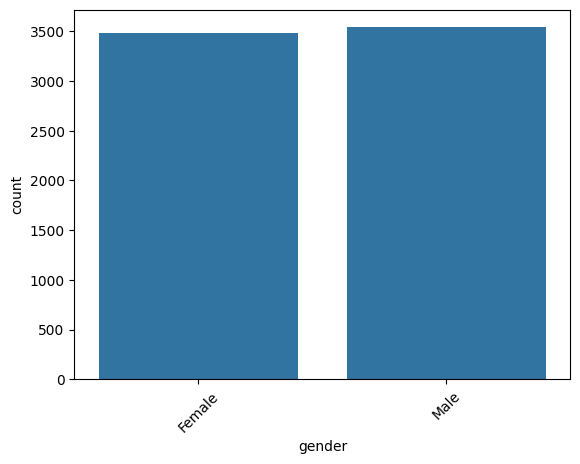

         Partner  Ratio
Partner                
No          3619 51.545
Yes         3402 48.455
##########################################


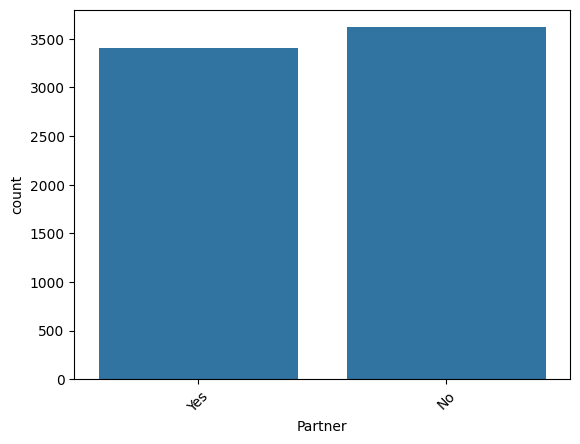

            Dependents  Ratio
Dependents                   
No                4911 69.947
Yes               2110 30.053
##########################################


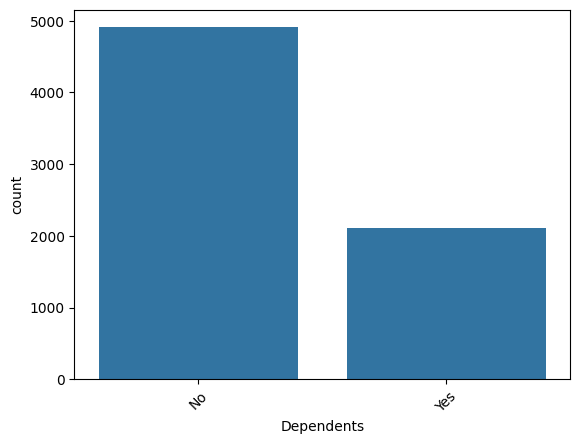

              PhoneService  Ratio
PhoneService                     
Yes                   6339 90.286
No                     682  9.714
##########################################


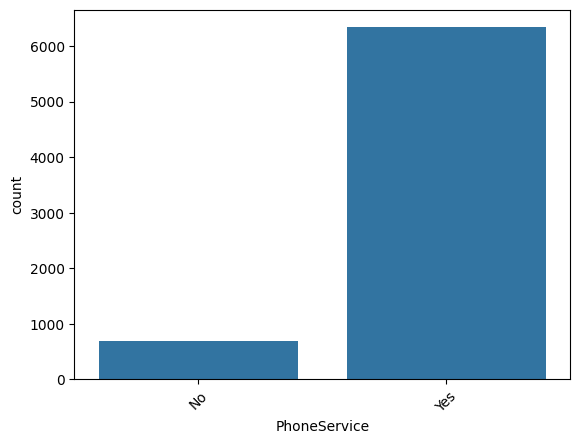

                  MultipleLines  Ratio
MultipleLines                         
No                         3368 47.970
Yes                        2971 42.316
No phone service            682  9.714
##########################################


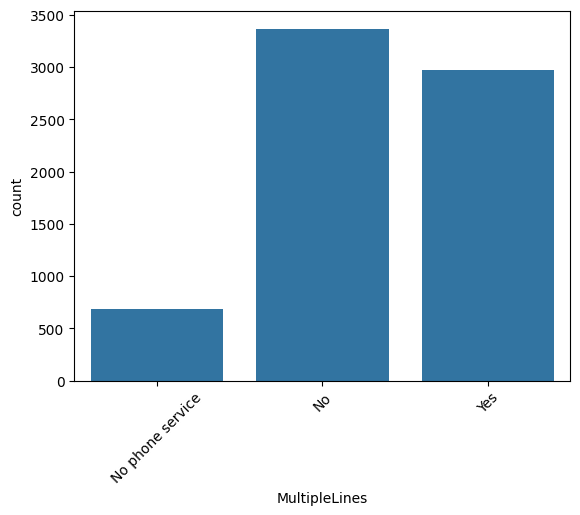

                 InternetService  Ratio
InternetService                        
Fiber optic                 3090 44.011
DSL                         2419 34.454
No                          1512 21.535
##########################################


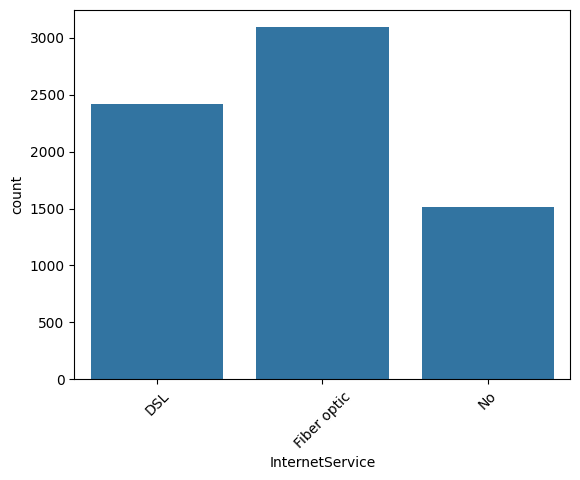

                     OnlineSecurity  Ratio
OnlineSecurity                            
No                             3490 49.708
Yes                            2019 28.757
No internet service            1512 21.535
##########################################


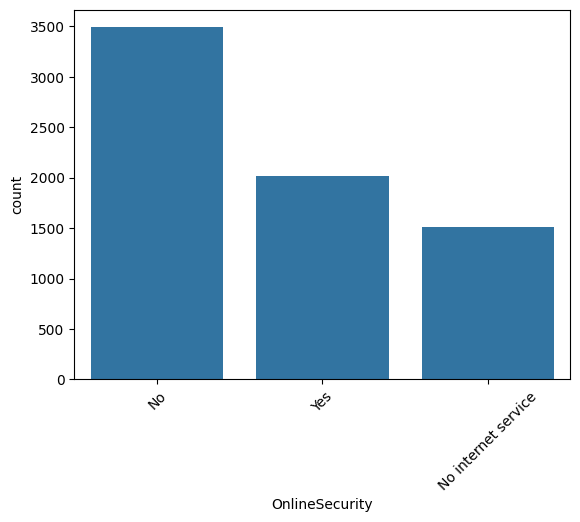

                     OnlineBackup  Ratio
OnlineBackup                            
No                           3080 43.868
Yes                          2429 34.596
No internet service          1512 21.535
##########################################


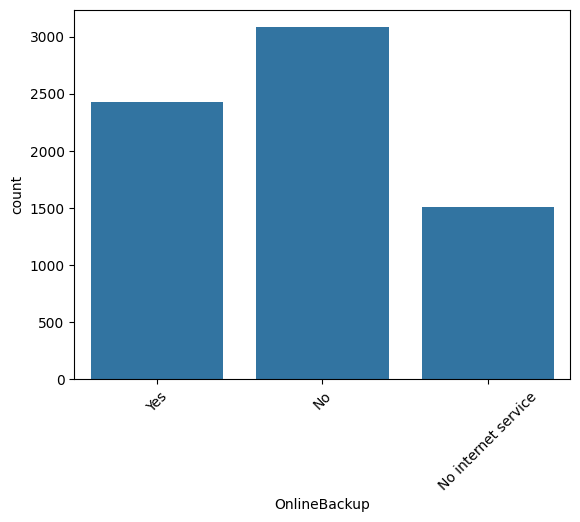

                     DeviceProtection  Ratio
DeviceProtection                            
No                               3087 43.968
Yes                              2422 34.497
No internet service              1512 21.535
##########################################


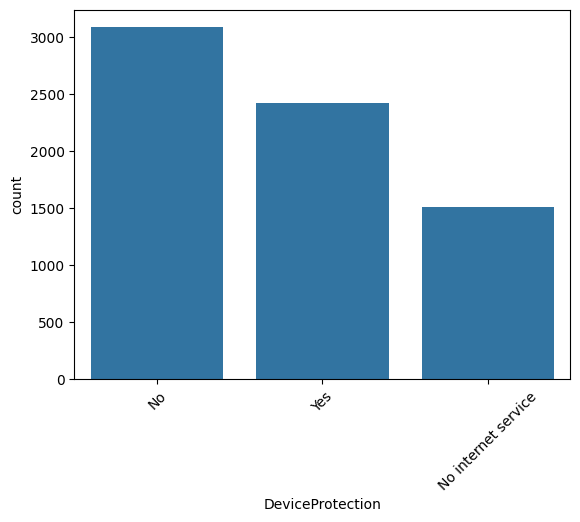

                     TechSupport  Ratio
TechSupport                            
No                          3465 49.352
Yes                         2044 29.113
No internet service         1512 21.535
##########################################


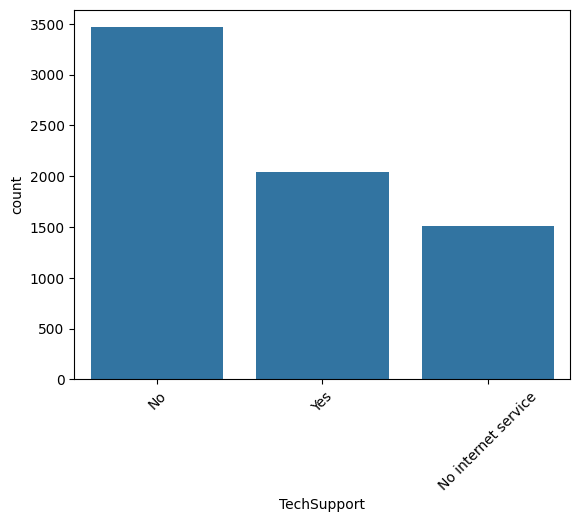

                     StreamingTV  Ratio
StreamingTV                            
No                          2802 39.909
Yes                         2707 38.556
No internet service         1512 21.535
##########################################


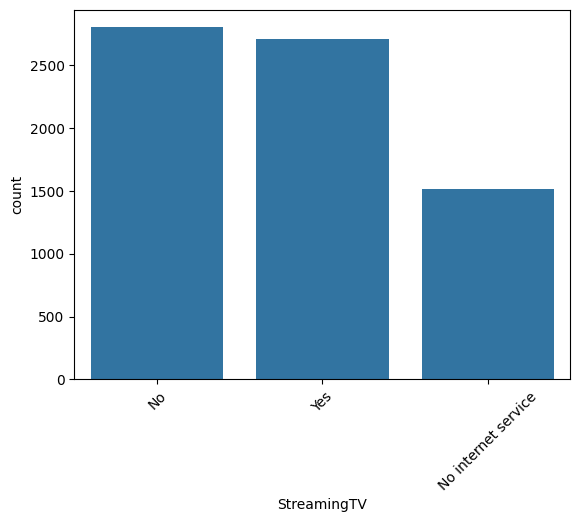

                     StreamingMovies  Ratio
StreamingMovies                            
No                              2777 39.553
Yes                             2732 38.912
No internet service             1512 21.535
##########################################


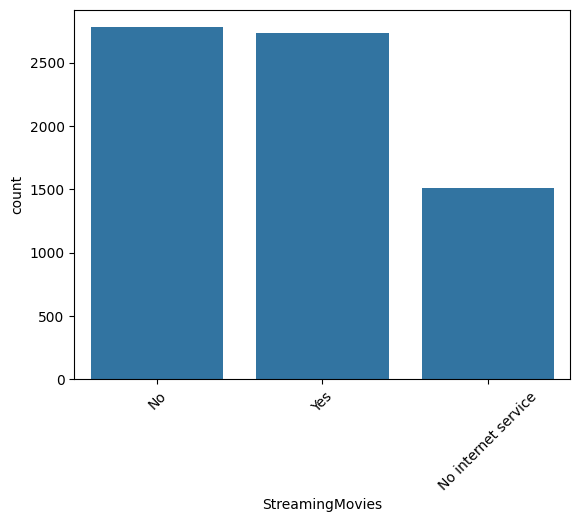

                Contract  Ratio
Contract                       
Month-to-month      3853 54.878
Two year            1695 24.142
One year            1473 20.980
##########################################


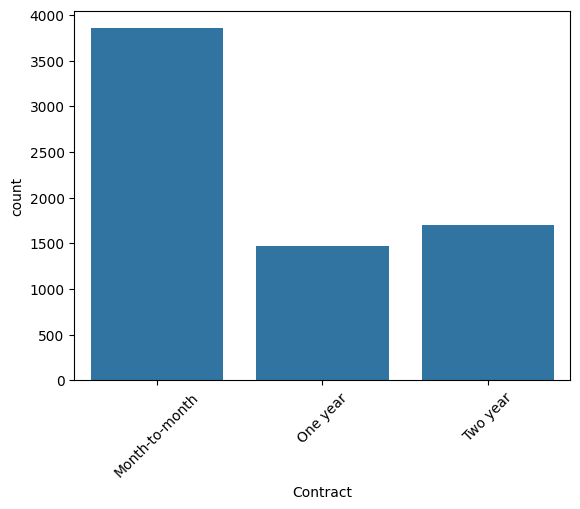

                  PaperlessBilling  Ratio
PaperlessBilling                         
Yes                           4161 59.265
No                            2860 40.735
##########################################


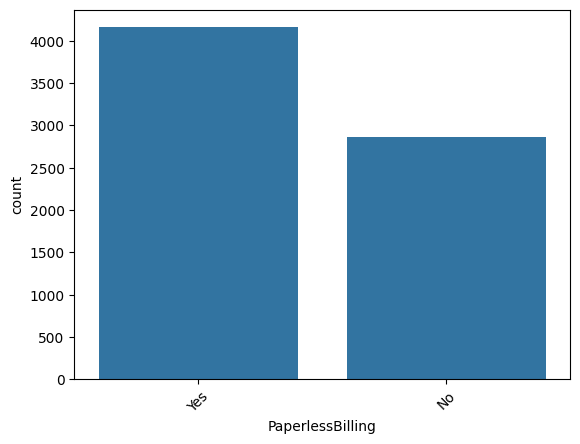

                           PaymentMethod  Ratio
PaymentMethod                                  
Electronic check                    2359 33.599
Mailed check                        1596 22.732
Bank transfer (automatic)           1544 21.991
Credit card (automatic)             1522 21.678
##########################################


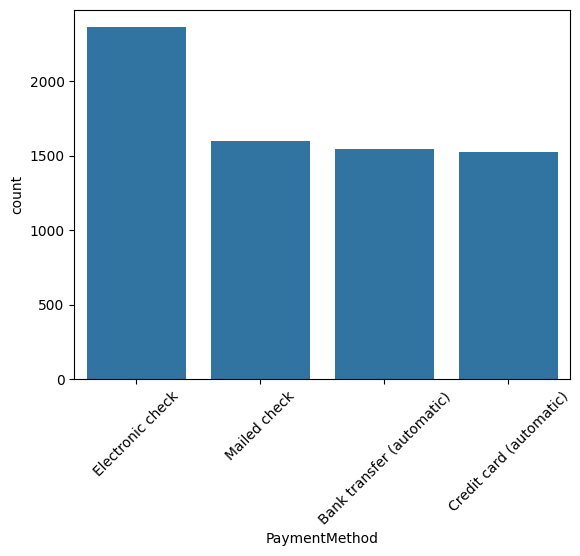

               SeniorCitizen  Ratio
SeniorCitizen                      
0                       5880 83.749
1                       1141 16.251
##########################################


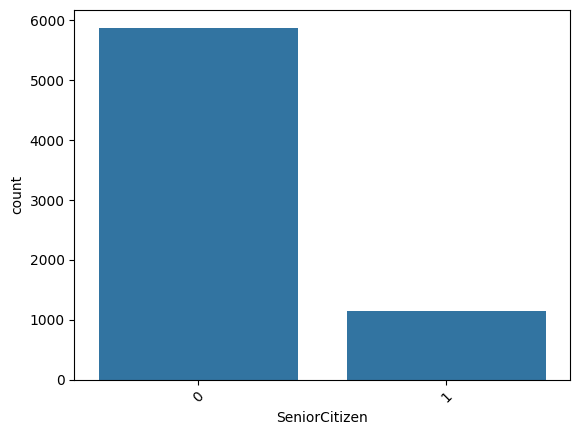

       Churn  Ratio
Churn              
0       5164 73.551
1       1857 26.449
##########################################


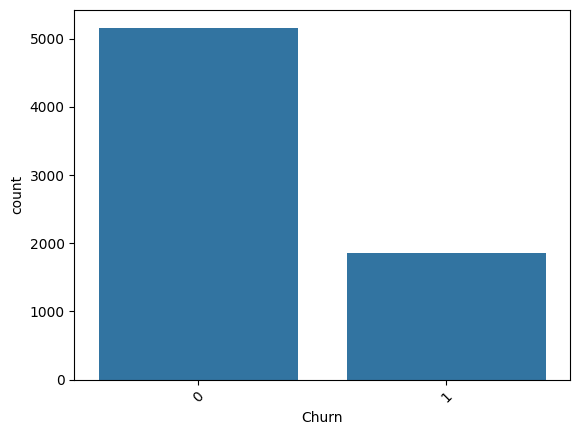

In [ ]:
def cat_summary(dataframe, col_name, plot=True):
    print(pd.DataFrame({
        col_name: dataframe[col_name].value_counts(),
        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)
    }))
    print("##########################################")

    if plot:
        sns.countplot(x=dataframe[col_name])
        plt.xticks(rotation=45)
        plt.show()

for col in cat_cols:
    cat_summary(df, col)

**7. OUTLIER ANALİZİ**

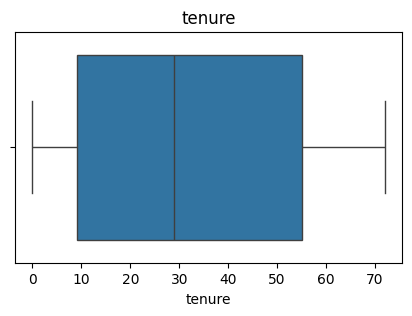

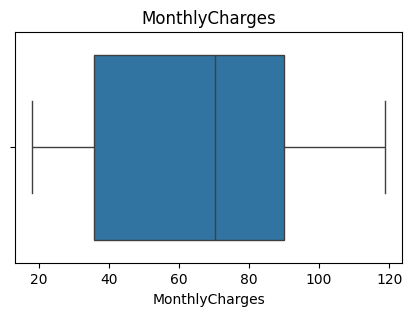

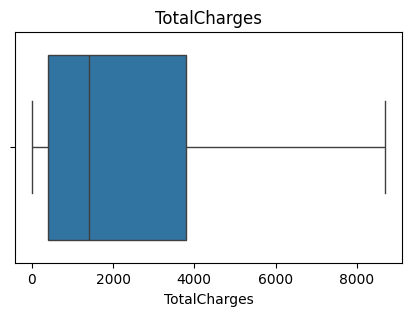

In [ ]:
# sadece gerçekten continuous değişkenleri al
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# binary değişkeni çıkar
num_cols = [col for col in num_cols if df[col].nunique() > 2]

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**8. SAYISAL DEĞİŞKEN ANALİZİ**


tenure özeti:
count   7021.000
mean      32.469
std       24.535
min        0.000
25%        9.000
50%       29.000
75%       55.000
max       72.000
Name: tenure, dtype: float64


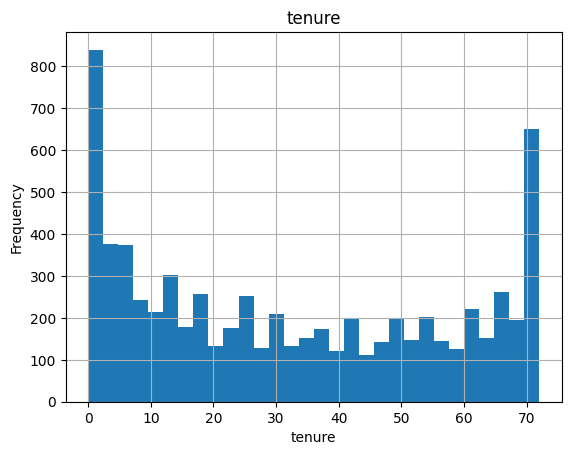


MonthlyCharges özeti:
count   7021.000
mean      64.852
std       30.069
min       18.250
25%       35.750
50%       70.400
75%       89.900
max      118.750
Name: MonthlyCharges, dtype: float64


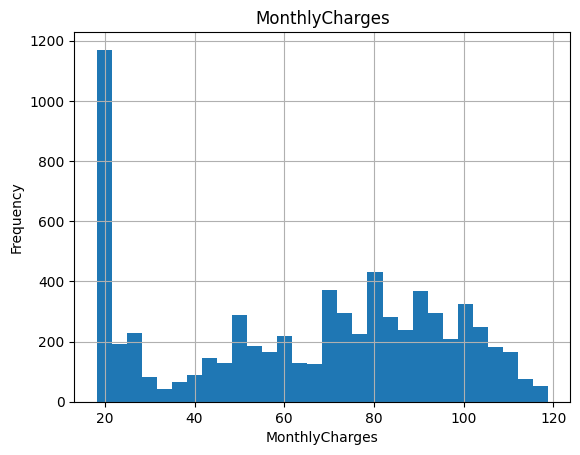


TotalCharges özeti:
count   7021.000
mean    2288.954
std     2265.319
min       18.800
25%      411.150
50%     1400.550
75%     3801.700
max     8684.800
Name: TotalCharges, dtype: float64


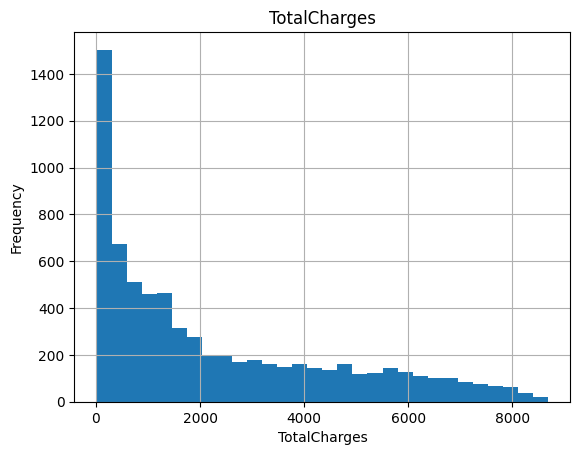

In [ ]:
import matplotlib.pyplot as plt

def num_summary(df, col, plot=True):
    print(f"\n{col} özeti:")
    print(df[col].describe())

    if plot:
        plt.figure()
        df[col].hist(bins=30)
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

# tüm sayısal değişkenler için
for col in num_cols:
    num_summary(df, col)

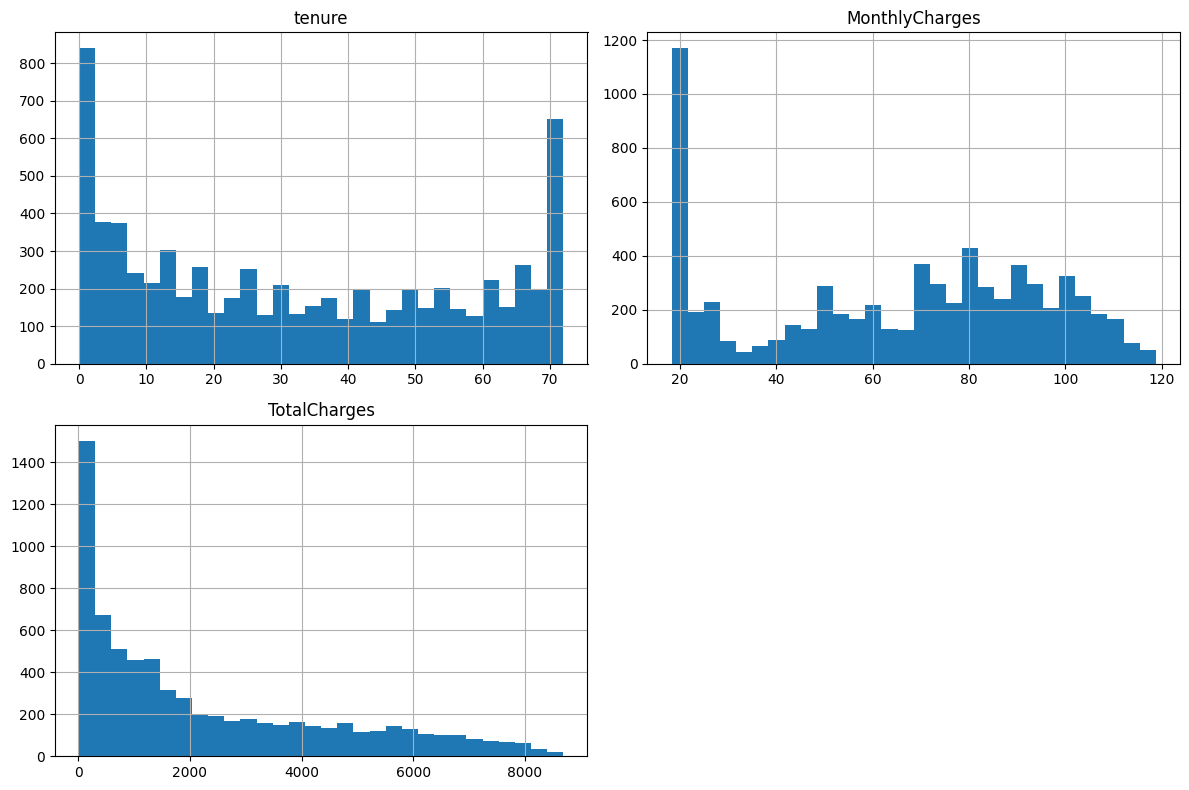

In [ ]:
df[num_cols].describe().T
df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

**9. CHURN ANALİZİ**

**Kategorik vs Churn**

In [ ]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(pd.DataFrame({
        "Churn_Rate": dataframe.groupby(categorical_col)[target].mean()
    }))
    print("##########################################")

for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

        Churn_Rate
gender            
Female       0.268
Male         0.261
##########################################
         Churn_Rate
Partner            
No            0.328
Yes           0.197
##########################################
            Churn_Rate
Dependents            
No               0.312
Yes              0.155
##########################################
              Churn_Rate
PhoneService            
No                 0.249
Yes                0.266
##########################################
                  Churn_Rate
MultipleLines               
No                     0.249
No phone service       0.249
Yes                    0.286
##########################################
                 Churn_Rate
InternetService            
DSL                   0.189
Fiber optic           0.418
No                    0.072
##########################################
                     Churn_Rate
OnlineSecurity                 
No                        0.416
No internet s

**Sayısal vs Churn**

In [ ]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target)[numerical_col].mean())
    print("##########################################")

for col in num_cols:
    target_summary_with_num(df, "Churn", col)

Churn
0   37.641
1   18.089
Name: tenure, dtype: float64
##########################################
Churn
0   61.345
1   74.604
Name: MonthlyCharges, dtype: float64
##########################################
Churn
0   2557.787
1   1541.377
Name: TotalCharges, dtype: float64
##########################################


**10. KORELASYON ANALİZİ**

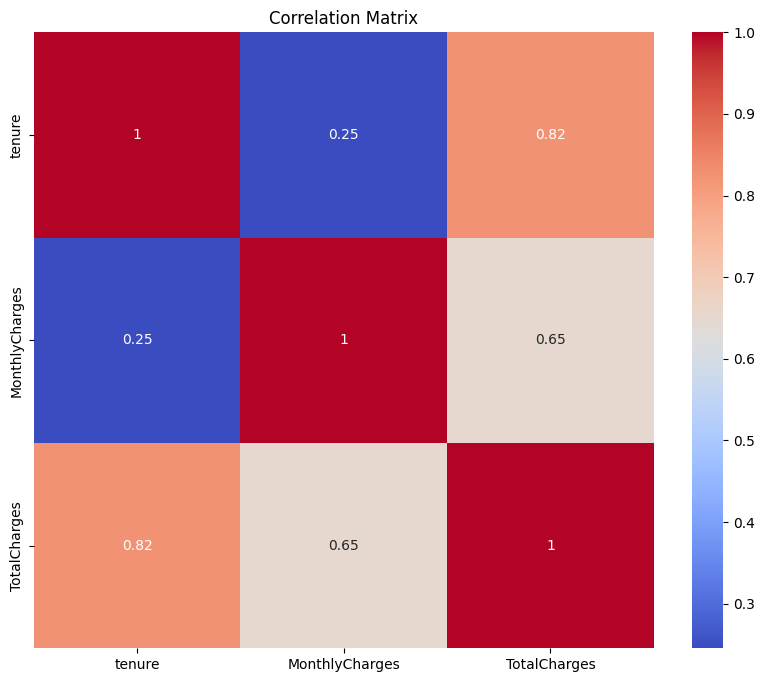

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**11. FEATURE ENGINEERING**

In [ ]:
df["NewCustomer"] = df["tenure"].apply(lambda x: 1 if x < 12 else 0)
df["AvgCharges"] = df["TotalCharges"] / (df["tenure"] + 1)

In [ ]:
df.head() #kontrol

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NewCustomer,AvgCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.850,0,1,14.925
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.500,0,0,53.986
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.150,1,1,36.050
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.750,0,0,40.016
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.650,1,1,50.550


**12. ENCODING**

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head() #kontrol

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,NewCustomer,AvgCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.850,29.850,0,1,14.925,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.950,1889.500,0,0,53.986,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.850,108.150,1,1,36.050,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.300,1840.750,0,0,40.016,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.700,151.650,1,1,50.550,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


**13. TRAIN-TEST SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((5616, 32), (1405, 32))

In [ ]:
print(X_train.shape)
print(X_test.shape)

(5616, 32)
(1405, 32)
